# استخراج ویژگی و کاهش بُعد با Scikit-learn

در این نوت‌بوک، مجموعه‌ای از روش‌های مهم استخراج ویژگی و کاهش بُعد بررسی می‌شوند. هدف این است که داده‌های پُربعد به نمایش‌ها و ویژگی‌های فشرده‌تر تبدیل شوند؛ به شکلی که ساختار اصلی داده تا حد ممکن حفظ شود و تحلیل، تصویرسازی یا مدل‌سازی ساده‌تر شود.

دیتاست مورد استفاده `Digits` از `sklearn.datasets` است. هر نمونه یک تصویر ۸ در ۸ پیکسل از یک رقم دست‌نویس است و به صورت یک بردار ۶۴ بعدی ذخیره شده است. این دیتاست برای مقایسه روش‌های کاهش بُعد مناسب است، زیرا هم ساختار تصویری دارد و هم برچسب کلاس‌ها برای ارزیابی کیفی و کمی در دسترس هستند.

روش‌های اصلی این نوت‌بوک:

- PCA
- Incremental PCA
- Truncated SVD
- NMF
- FastICA
- Linear Discriminant Analysis
- Kernel PCA
- Isomap
- Locally Linear Embedding
- t-SNE

در پایان، روش‌ها از نظر کاربرد، تفسیرپذیری، حفظ ساختار، قابلیت استفاده برای مدل‌سازی و محدودیت‌ها مقایسه می‌شوند.

## ۱. آماده‌سازی کتابخانه‌ها

در این بخش کتابخانه‌های مورد نیاز وارد می‌شوند. تمام روش‌های اصلی از `scikit-learn` استفاده می‌کنند. برای رسم نمودار از `matplotlib` و `seaborn` استفاده می‌شود.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.datasets import load_digits
from sklearn.decomposition import FastICA, IncrementalPCA, NMF, PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import Isomap, LocallyLinearEmbedding, TSNE, trustworthiness
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import KernelPCA

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

## ۲. بارگذاری دیتاست و مشاهده اولیه

داده خام شامل ۱۷۹۷ نمونه و ۶۴ ویژگی است. هر ویژگی شدت روشنایی یک پیکسل را نشان می‌دهد. مقدار پیکسل‌ها در این دیتاست بین ۰ و ۱۶ است.

از آنجا که بسیاری از روش‌های کاهش بُعد به مقیاس ویژگی‌ها حساس هستند، نسخه استانداردشده داده نیز ساخته می‌شود.

In [2]:
digits = load_digits()
X = digits.data
y = digits.target
images = digits.images
class_names = digits.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

minmax_scaler = MinMaxScaler()
X_nonnegative = minmax_scaler.fit_transform(X)

print("X shape:", X.shape)
print("Number of classes:", len(np.unique(y)))
print("Pixel value range:", X.min(), "to", X.max())

class_counts = pd.Series(y).value_counts().sort_index()
display(pd.DataFrame({"digit": class_counts.index, "count": class_counts.values}))

X shape: (1797, 64)
Number of classes: 10
Pixel value range: 0.0 to 16.0


,digit,count
0,0,178
1,1,182
2,2,177
3,3,183
4,4,181
5,5,182
6,6,181
7,7,179
8,8,174
9,9,180


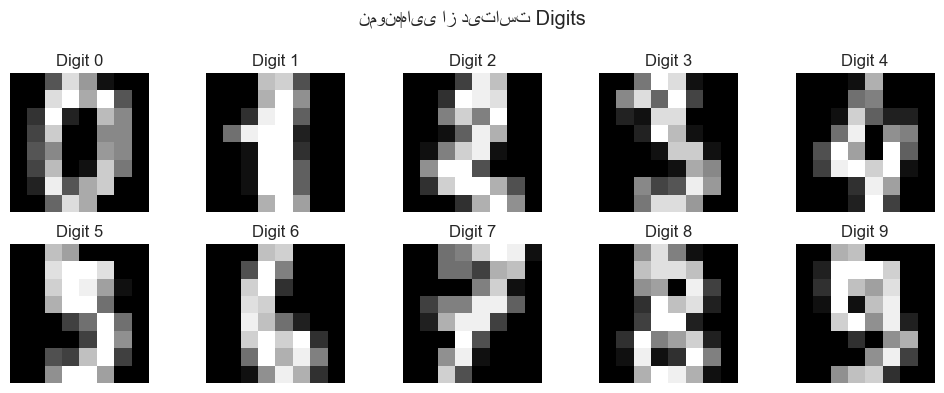

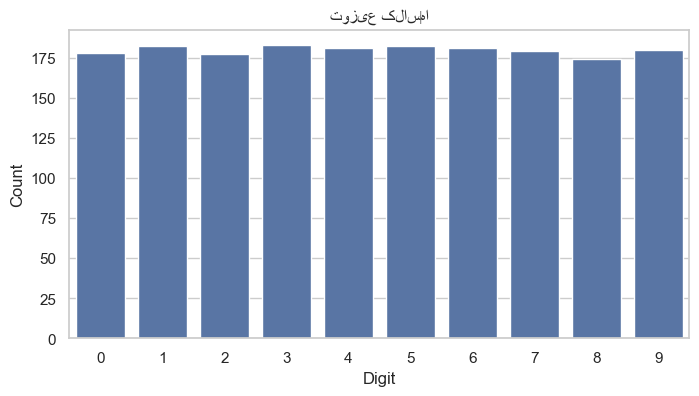

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(y == digit)[0][0]
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")
plt.suptitle("نمونه‌هایی از دیتاست Digits")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, color="#4C72B0")
plt.title("توزیع کلاس‌ها")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

### نتیجه‌گیری بخش داده

داده‌ها چندکلاسه و تقریبا متوازن هستند. هر نمونه ۶۴ ویژگی دارد؛ بنابراین کاهش بُعد می‌تواند برای تصویرسازی دوبعدی، فشرده‌سازی اطلاعات، حذف نویز و ساخت ویژگی‌های جدید مفید باشد. چون داده تصویری است، برخی روش‌ها مانند PCA و NMF علاوه بر کاهش بُعد، تفسیر بصری نیز ارائه می‌دهند.

## ۳. توابع کمکی برای تصویرسازی و ارزیابی

برای مقایسه روش‌ها، چند تابع کمکی تعریف می‌شود:

- رسم embedding دوبعدی
- رسم مؤلفه‌های استخراج‌شده به شکل تصویر ۸ در ۸
- ارزیابی کیفیت embedding با معیار `trustworthiness`
- ارزیابی عملکرد ویژگی‌های استخراج‌شده در یک مدل طبقه‌بندی ساده

معیار `trustworthiness` بررسی می‌کند که همسایگی‌های محلی داده اصلی تا چه حد در فضای کاهش‌یافته حفظ شده‌اند. مقدار آن بین ۰ و ۱ است و مقدار بالاتر بهتر است.

In [4]:
def plot_2d_embedding(Z, y, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        Z[:, 0],
        Z[:, 1],
        c=y,
        cmap="tab10",
        s=18,
        alpha=0.85,
        edgecolor="none",
    )
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    return scatter


def plot_digit_components(components, title, n_components=10):
    n_components = min(n_components, len(components))
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.ravel()):
        if i < n_components:
            ax.imshow(components[i].reshape(8, 8), cmap="viridis")
            ax.set_title(f"C{i + 1}")
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def classifier_report_for_features(Z, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        Z,
        y,
        test_size=0.25,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    return {
        "method": name,
        "n_features": Z.shape[1],
        "knn_accuracy": accuracy_score(y_test, pred),
        "knn_f1_macro": f1_score(y_test, pred, average="macro"),
    }


def timed_fit_transform(estimator, X_input, name):
    start = time.perf_counter()
    Z = estimator.fit_transform(X_input)
    elapsed = time.perf_counter() - start
    print(f"{name}: shape={Z.shape}, time={elapsed:.3f}s")
    return Z, elapsed

## ۴. PCA: Principal Component Analysis

PCA یک روش خطی و بدون‌ناظر برای کاهش بُعد است. این روش محورهایی را پیدا می‌کند که بیشترین واریانس داده را توضیح می‌دهند. مؤلفه اول بیشترین واریانس ممکن را نگه می‌دارد، مؤلفه دوم بیشترین واریانس باقی‌مانده را، و به همین ترتیب.

کاربردهای PCA:

- کاهش بُعد قبل از مدل‌سازی
- حذف نویز
- تصویرسازی داده در ۲ یا ۳ بعد
- فشرده‌سازی داده
- تحلیل میزان اطلاعات موجود در مؤلفه‌ها

محدودیت اصلی PCA این است که فقط ساختارهای خطی را مدل می‌کند.

PCA 2D: shape=(1797, 2), time=0.025s


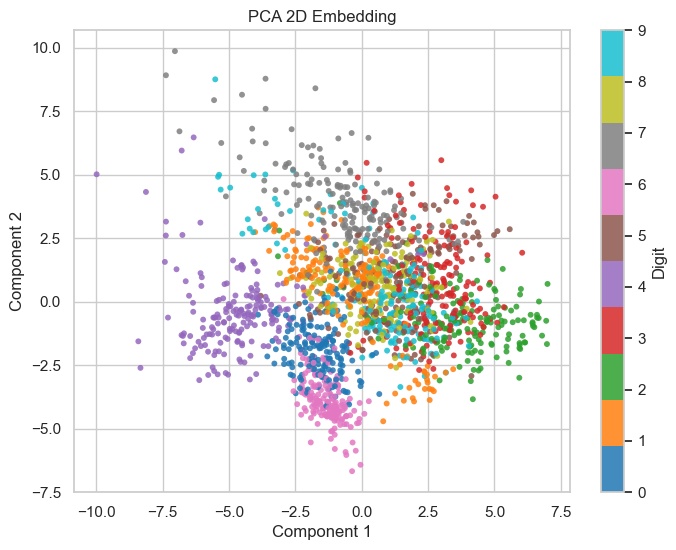

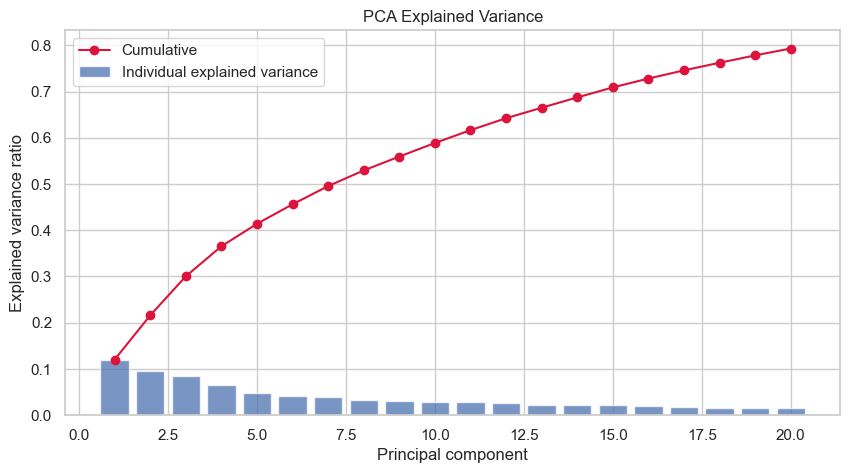

Components needed for 80% variance: 21
Components needed for 90% variance: 31
Components needed for 95% variance: 40


In [5]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca_2d, pca_time = timed_fit_transform(pca_2d, X_scaled, "PCA 2D")

scatter = plot_2d_embedding(Z_pca_2d, y, "PCA 2D Embedding")
plt.colorbar(scatter, label="Digit")
plt.show()

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 21), explained[:20], alpha=0.75, label="Individual explained variance")
plt.plot(range(1, 21), cumulative[:20], marker="o", color="crimson", label="Cumulative")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Explained Variance")
plt.legend()
plt.show()

for threshold in [0.80, 0.90, 0.95]:
    n_needed = np.argmax(cumulative >= threshold) + 1
    print(f"Components needed for {threshold:.0%} variance:", n_needed)

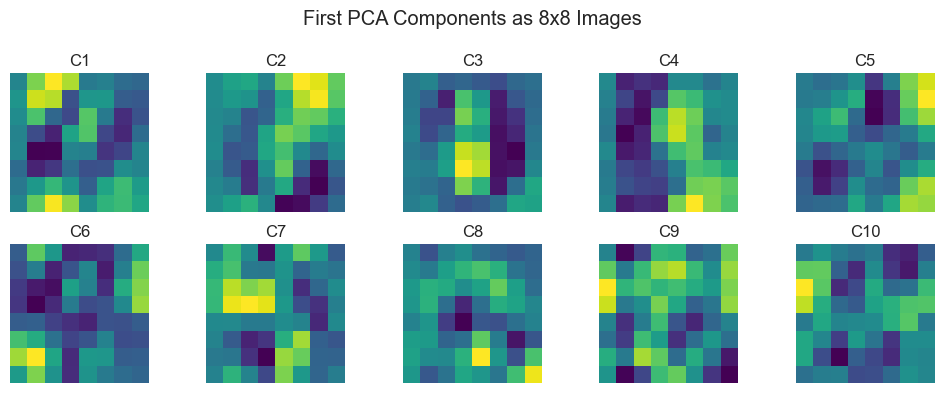

In [6]:
plot_digit_components(
    pca_full.components_[:10],
    "First PCA Components as 8x8 Images",
    n_components=10,
)

### نتیجه‌گیری PCA

PCA نشان می‌دهد چه تعداد مؤلفه برای حفظ درصد مشخصی از واریانس لازم است. در دیتاست Digits، تعداد محدودی مؤلفه می‌تواند بخش بزرگی از واریانس را توضیح دهد؛ یعنی داده دارای افزونگی و ساختار داخلی است.

در تصویر دوبعدی PCA، برخی کلاس‌ها از هم جدا می‌شوند، اما هم‌پوشانی نیز وجود دارد. این نتیجه طبیعی است، زیرا فشرده‌سازی ۶۴ بعد به ۲ بعد بخشی از اطلاعات را حذف می‌کند. PCA برای تصویرسازی سریع و کاهش بُعد اولیه بسیار مناسب است، اما همیشه بهترین جداسازی کلاسی را تضمین نمی‌کند.

## ۵. بازسازی داده با PCA و مفهوم فشرده‌سازی

یکی از مزیت‌های PCA امکان بازسازی تقریبی داده از مؤلفه‌های کاهش‌یافته است. هرچه تعداد مؤلفه‌ها بیشتر باشد، بازسازی دقیق‌تر است؛ اما فشرده‌سازی کمتر می‌شود.

این بخش نشان می‌دهد با ۵، ۱۵، ۳۰ و ۵۰ مؤلفه، تصویر بازسازی‌شده چه کیفیتی دارد.

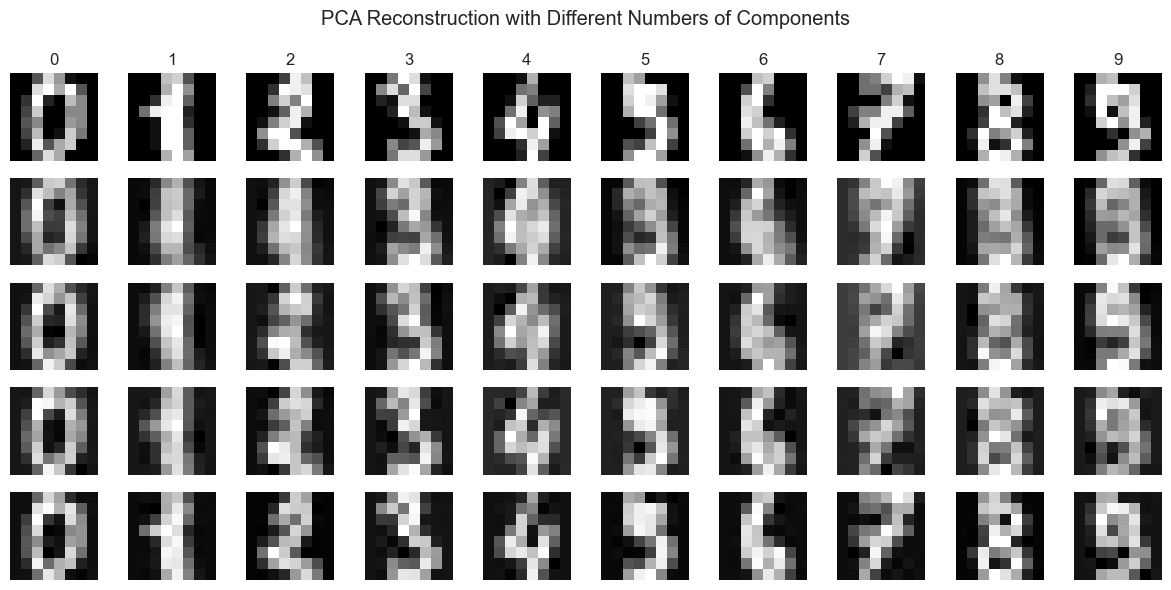

In [7]:
sample_indices = [np.where(y == digit)[0][0] for digit in range(10)]
component_choices = [5, 15, 30, 50]

fig, axes = plt.subplots(len(component_choices) + 1, 10, figsize=(12, 6))

for col, idx in enumerate(sample_indices):
    axes[0, col].imshow(X[idx].reshape(8, 8), cmap="gray")
    axes[0, col].set_title(f"{y[idx]}")
    axes[0, col].axis("off")
axes[0, 0].set_ylabel("Original", rotation=0, labelpad=35)

for row, n_comp in enumerate(component_choices, start=1):
    pca_reconstruct = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_comp, random_state=RANDOM_STATE)),
        ]
    )
    X_reduced = pca_reconstruct.fit_transform(X)
    X_back_scaled = pca_reconstruct.named_steps["pca"].inverse_transform(X_reduced)
    X_back = pca_reconstruct.named_steps["scaler"].inverse_transform(X_back_scaled)
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(X_back[idx].reshape(8, 8), cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"{n_comp} PCs", rotation=0, labelpad=35)

plt.suptitle("PCA Reconstruction with Different Numbers of Components")
plt.tight_layout()
plt.show()

### نتیجه‌گیری بازسازی PCA

با تعداد کم مؤلفه، شکل کلی رقم حفظ می‌شود اما جزئیات از بین می‌رود. با افزایش تعداد مؤلفه‌ها، بازسازی به تصویر اصلی نزدیک‌تر می‌شود. این رفتار نشان می‌دهد PCA می‌تواند برای فشرده‌سازی و حذف نویز مفید باشد، اما انتخاب تعداد مؤلفه‌ها باید بین فشرده‌سازی و حفظ اطلاعات تعادل ایجاد کند.

## ۶. Incremental PCA

Incremental PCA نسخه‌ای از PCA است که داده را به صورت batch پردازش می‌کند. این روش زمانی مفید است که کل داده در حافظه جا نمی‌شود یا حجم داده بسیار زیاد است.

در دیتاست کوچک Digits تفاوت عملی بزرگی دیده نمی‌شود، اما مفهوم آن برای داده‌های بزرگ مهم است.

Incremental PCA 2D: shape=(1797, 2), time=0.098s


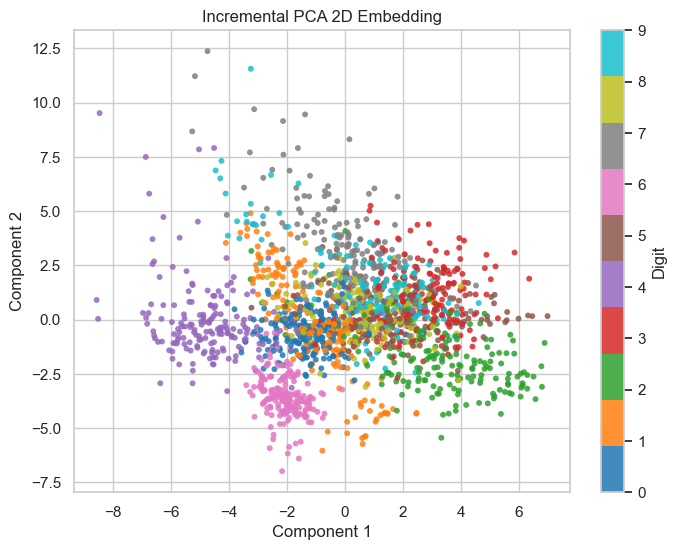

In [8]:
ipca = IncrementalPCA(n_components=2, batch_size=128)
Z_ipca_2d, ipca_time = timed_fit_transform(ipca, X_scaled, "Incremental PCA 2D")

scatter = plot_2d_embedding(Z_ipca_2d, y, "Incremental PCA 2D Embedding")
plt.colorbar(scatter, label="Digit")
plt.show()

### نتیجه‌گیری Incremental PCA

Incremental PCA از نظر هدف مشابه PCA است، اما برای شرایطی طراحی شده که داده بزرگ است. اگر محدودیت حافظه وجود نداشته باشد، PCA معمولی ساده‌تر است. اگر داده بسیار بزرگ یا stream-like باشد، Incremental PCA انتخاب مناسب‌تری است.

## ۷. Truncated SVD

Truncated SVD از نظر کاربرد به PCA نزدیک است، اما برخلاف PCA الزاما داده را center نمی‌کند. این ویژگی باعث می‌شود برای ماتریس‌های sparse بسیار مناسب باشد؛ مثلا در متن‌کاوی و مدل Bag-of-Words یا TF-IDF.

کاربردهای رایج Truncated SVD:

- کاهش بُعد داده‌های sparse
- Latent Semantic Analysis در پردازش متن
- استخراج ساختارهای پنهان خطی

Truncated SVD 2D: shape=(1797, 2), time=0.014s


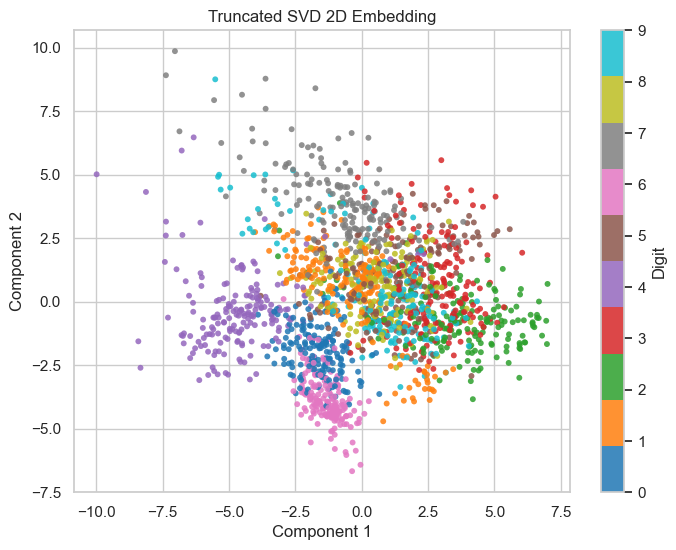

Explained variance with 30 SVD components: 0.8932


In [9]:
svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
Z_svd_2d, svd_time = timed_fit_transform(svd_2d, X_scaled, "Truncated SVD 2D")

scatter = plot_2d_embedding(Z_svd_2d, y, "Truncated SVD 2D Embedding")
plt.colorbar(scatter, label="Digit")
plt.show()

svd_30 = TruncatedSVD(n_components=30, random_state=RANDOM_STATE)
svd_30.fit(X_scaled)
print("Explained variance with 30 SVD components:", round(svd_30.explained_variance_ratio_.sum(), 4))

### نتیجه‌گیری Truncated SVD

در داده‌های dense مانند Digits، خروجی SVD می‌تواند به PCA نزدیک باشد. مزیت اصلی SVD در داده‌های sparse ظاهر می‌شود؛ جایی که PCA معمولی به دلیل center کردن داده، sparsity را از بین می‌برد. بنابراین انتخاب بین PCA و SVD به نوع داده وابسته است.

## ۸. NMF: Non-negative Matrix Factorization

NMF داده را به ترکیبی از مؤلفه‌های غیرمنفی تجزیه می‌کند. چون هم داده ورودی و هم مؤلفه‌ها غیرمنفی هستند، NMF معمولا نمایش part-based ایجاد می‌کند؛ یعنی هر مؤلفه بخشی از الگو را توضیح می‌دهد.

کاربردهای NMF:

- استخراج topic در متن
- استخراج بخش‌های تصویر
- داده‌هایی که ذاتا غیرمنفی هستند، مانند شدت پیکسل، شمارش کلمات یا مقادیر طیفی

برای NMF، داده باید غیرمنفی باشد. در اینجا از نسخه MinMax شده داده استفاده می‌شود.

NMF 2D: shape=(1797, 2), time=0.054s


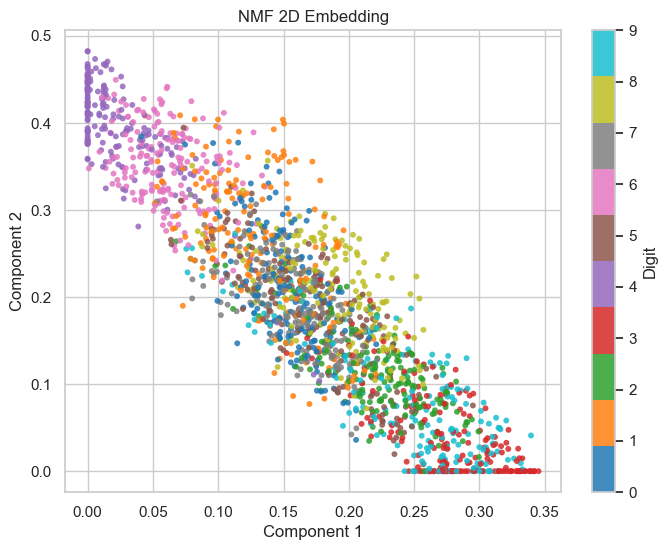

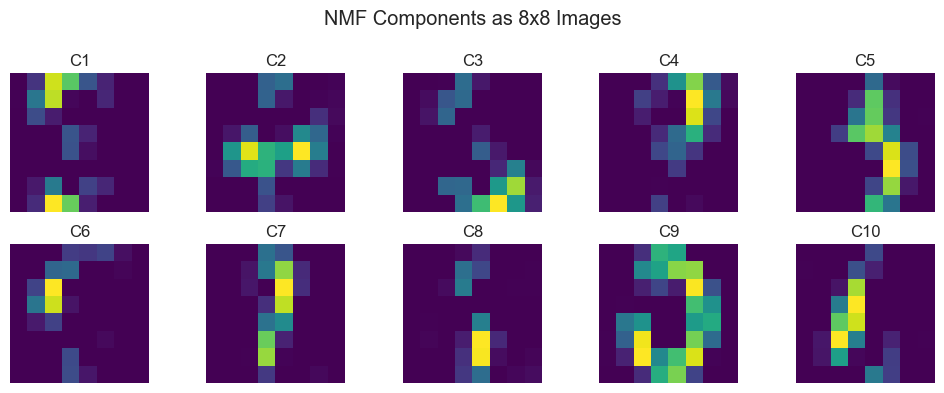

In [10]:
nmf_2d = NMF(n_components=2, init="nndsvda", max_iter=1000, random_state=RANDOM_STATE)
Z_nmf_2d, nmf_time = timed_fit_transform(nmf_2d, X_nonnegative, "NMF 2D")

scatter = plot_2d_embedding(Z_nmf_2d, y, "NMF 2D Embedding")
plt.colorbar(scatter, label="Digit")
plt.show()

nmf_10 = NMF(n_components=10, init="nndsvda", max_iter=1000, random_state=RANDOM_STATE)
Z_nmf_10 = nmf_10.fit_transform(X_nonnegative)
plot_digit_components(nmf_10.components_, "NMF Components as 8x8 Images", n_components=10)

### نتیجه‌گیری NMF

NMF در مقایسه با PCA مؤلفه‌هایی غیرمنفی و گاهی تفسیرپذیرتر تولید می‌کند. در تصاویر، مؤلفه‌های NMF می‌توانند بخش‌هایی از الگوهای روشنایی را نشان دهند. با این حال NMF برای همه داده‌ها مناسب نیست؛ شرط غیرمنفی بودن داده و حساسیت به مقداردهی اولیه از محدودیت‌های آن است.

## ۹. FastICA: Independent Component Analysis

ICA به دنبال مؤلفه‌هایی است که تا حد ممکن از نظر آماری مستقل باشند. در حالی که PCA مؤلفه‌های نامرتبط از نظر واریانس پیدا می‌کند، ICA استقلال آماری را هدف قرار می‌دهد.

کاربردهای ICA:

- جداسازی سیگنال‌ها
- حذف نویز یا artifact در سیگنال‌های زیستی
- استخراج منابع مستقل پنهان

برای داده تصویری Digits، ICA بیشتر جنبه مقایسه‌ای دارد.

FastICA 2D: shape=(1797, 2), time=0.036s


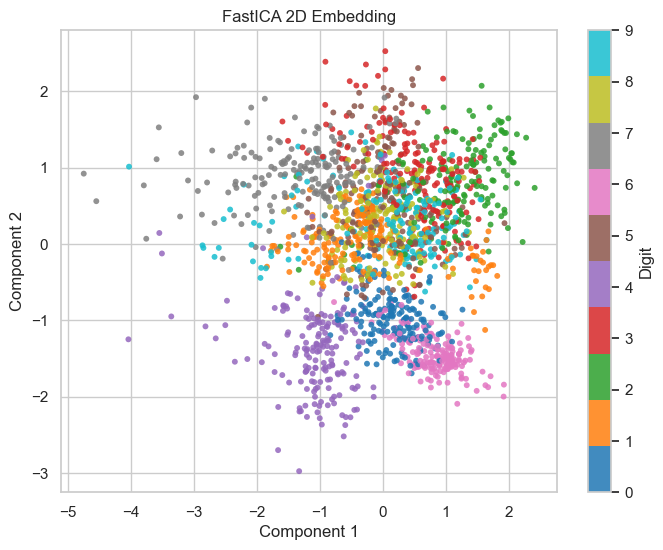

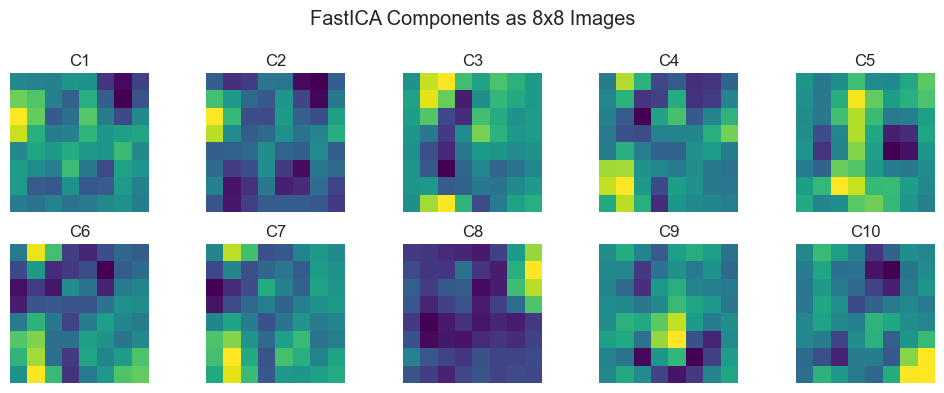

In [11]:
ica_2d = FastICA(n_components=2, random_state=RANDOM_STATE, max_iter=1000, whiten="unit-variance")
Z_ica_2d, ica_time = timed_fit_transform(ica_2d, X_scaled, "FastICA 2D")

scatter = plot_2d_embedding(Z_ica_2d, y, "FastICA 2D Embedding")
plt.colorbar(scatter, label="Digit")
plt.show()

ica_10 = FastICA(n_components=10, random_state=RANDOM_STATE, max_iter=1000, whiten="unit-variance")
ica_10.fit(X_scaled)
plot_digit_components(ica_10.components_, "FastICA Components as 8x8 Images", n_components=10)

### نتیجه‌گیری FastICA

ICA زمانی ارزشمندتر است که داده از ترکیب چند منبع مستقل تولید شده باشد. در دیتاست Digits، جداسازی کلاس‌ها با ICA لزوما بهتر از PCA نیست، اما مؤلفه‌ها می‌توانند الگوهای متفاوتی از ساختار داده را آشکار کنند. ICA بیشتر برای مسائل سیگنال و جداسازی منبع مناسب است.

## ۱۰. LDA: Linear Discriminant Analysis به عنوان استخراج ویژگی نظارت‌شده

LDA برخلاف PCA و SVD یک روش نظارت‌شده است؛ یعنی از برچسب کلاس‌ها استفاده می‌کند. هدف LDA پیدا کردن محورهایی است که جداسازی کلاس‌ها را بیشینه کنند.

در مسئله‌ای با `C` کلاس، LDA حداکثر `C - 1` مؤلفه تولید می‌کند. برای Digits با ۱۰ کلاس، حداکثر ۹ مؤلفه وجود دارد.

کاربردهای LDA:

- کاهش بُعد با حفظ جداسازی کلاسی
- استخراج ویژگی برای طبقه‌بندی
- تصویرسازی نظارت‌شده

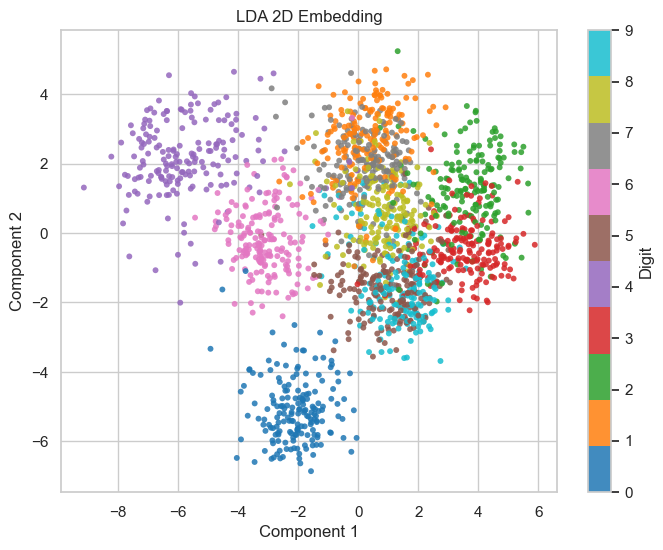

LDA transformed shape: (1797, 9)
Explained variance ratio sum: 1.0


In [12]:
lda_2d = LinearDiscriminantAnalysis(n_components=2)
Z_lda_2d = lda_2d.fit_transform(X_scaled, y)
lda_time = np.nan

scatter = plot_2d_embedding(Z_lda_2d, y, "LDA 2D Embedding")
plt.colorbar(scatter, label="Digit")
plt.show()

lda_9 = LinearDiscriminantAnalysis(n_components=9)
Z_lda_9 = lda_9.fit_transform(X_scaled, y)
print("LDA transformed shape:", Z_lda_9.shape)
print("Explained variance ratio sum:", round(lda_9.explained_variance_ratio_.sum(), 4))

### نتیجه‌گیری LDA

چون LDA از برچسب‌ها استفاده می‌کند، معمولا در نمایش دوبعدی جداسازی کلاسی واضح‌تری نسبت به روش‌های بدون‌ناظر ایجاد می‌کند. با این حال نباید آن را با PCA یکی دانست؛ PCA ساختار واریانس کل داده را حفظ می‌کند، اما LDA ساختاری را می‌جوید که برای تفکیک کلاس‌ها مفید باشد.

اگر هدف اصلی طبقه‌بندی باشد و برچسب‌ها در دسترس باشند، LDA می‌تواند روش استخراج ویژگی قدرتمندی باشد. اگر هدف کشف ساختار بدون برچسب باشد، PCA، SVD، NMF یا روش‌های manifold مناسب‌ترند.

## ۱۱. Kernel PCA

Kernel PCA نسخه غیرخطی PCA است. این روش با استفاده از kernel داده را به فضای ویژگی ضمنی منتقل می‌کند و سپس ساختارهای غیرخطی را استخراج می‌کند.

کاربردها:

- کاهش بُعد غیرخطی
- تصویرسازی داده‌هایی که با محورهای خطی به خوبی جدا نمی‌شوند
- استخراج ویژگی پیش از مدل‌های خطی

محدودیت‌ها:

- محاسبات سنگین‌تر از PCA
- انتخاب kernel و پارامترها اهمیت زیادی دارد
- تفسیرپذیری مؤلفه‌ها کمتر از PCA است

Kernel PCA 2D: shape=(1797, 2), time=0.303s


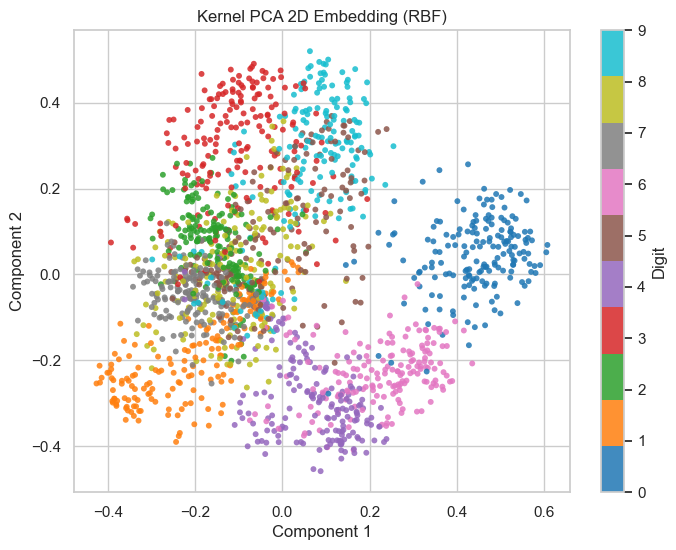

In [13]:
kpca_2d = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.02,
    eigen_solver="arpack",
    random_state=RANDOM_STATE,
)
Z_kpca_2d, kpca_time = timed_fit_transform(kpca_2d, X_scaled, "Kernel PCA 2D")

scatter = plot_2d_embedding(Z_kpca_2d, y, "Kernel PCA 2D Embedding (RBF)")
plt.colorbar(scatter, label="Digit")
plt.show()

### نتیجه‌گیری Kernel PCA

Kernel PCA می‌تواند ساختارهای غیرخطی را بهتر از PCA آشکار کند، اما حساسیت زیادی به انتخاب kernel و پارامترهایی مانند `gamma` دارد. اگر پارامترها مناسب نباشند، embedding ممکن است کیفیت خوبی نداشته باشد. این روش برای تحلیل غیرخطی مناسب است، اما برای pipelineهای بزرگ باید هزینه محاسباتی آن نیز در نظر گرفته شود.

## ۱۲. Isomap

Isomap یک روش manifold learning است. این روش تلاش می‌کند فاصله‌های ژئودزیک روی manifold را حفظ کند، نه صرفا فاصله اقلیدسی مستقیم در فضای اصلی.

کاربردها:

- کشف ساختارهای غیرخطی
- تصویرسازی داده‌هایی که روی یک manifold کم‌بُعد قرار دارند
- تحلیل داده‌هایی که فاصله محلی اهمیت زیادی دارد

پارامتر مهم Isomap تعداد همسایه‌هاست.

Isomap 2D: shape=(1797, 2), time=1.592s


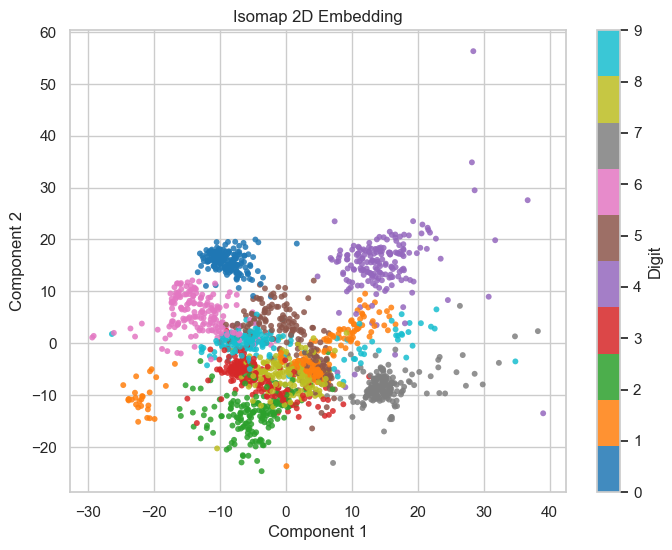

In [14]:
isomap_2d = Isomap(n_neighbors=10, n_components=2)
Z_isomap_2d, isomap_time = timed_fit_transform(isomap_2d, X_scaled, "Isomap 2D")

scatter = plot_2d_embedding(Z_isomap_2d, y, "Isomap 2D Embedding")
plt.colorbar(scatter, label="Digit")
plt.show()

### نتیجه‌گیری Isomap

Isomap می‌تواند ساختار غیرخطی داده را بهتر از روش‌های خطی نشان دهد، اما به تعداد همسایه‌ها حساس است. اگر تعداد همسایه‌ها خیلی کم باشد، گراف همسایگی ممکن است گسسته شود. اگر خیلی زیاد باشد، ساختار محلی از بین می‌رود و نتیجه به روش‌های خطی نزدیک‌تر می‌شود.

## ۱۳. Locally Linear Embedding

LLE فرض می‌کند هر نقطه را می‌توان با ترکیب خطی همسایه‌های نزدیکش بازسازی کرد. سپس تلاش می‌کند همین روابط محلی را در فضای کم‌بُعد حفظ کند.

کاربردها:

- کاهش بُعد غیرخطی
- حفظ ساختار محلی
- تصویرسازی manifold

محدودیت مهم LLE این است که به نویز و انتخاب تعداد همسایه‌ها حساس است.

LLE 2D: shape=(1797, 2), time=0.468s


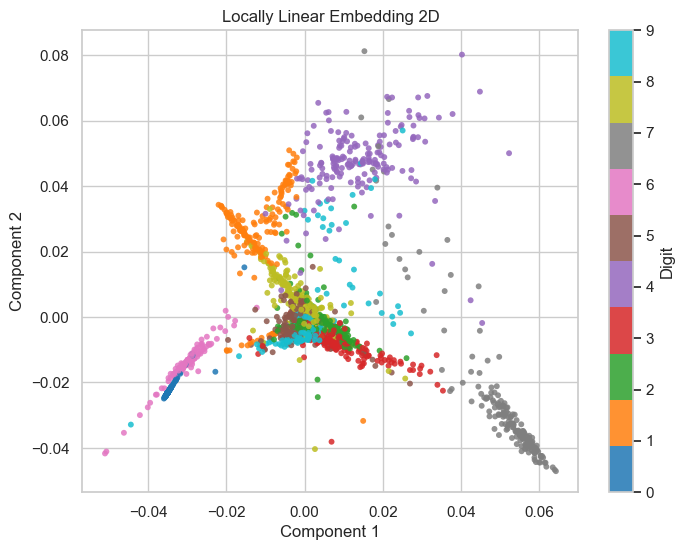

In [15]:
lle_2d = LocallyLinearEmbedding(
    n_neighbors=12,
    n_components=2,
    method="standard",
    eigen_solver="arpack",
    random_state=RANDOM_STATE,
)
Z_lle_2d, lle_time = timed_fit_transform(lle_2d, X_scaled, "LLE 2D")

scatter = plot_2d_embedding(Z_lle_2d, y, "Locally Linear Embedding 2D")
plt.colorbar(scatter, label="Digit")
plt.show()

### نتیجه‌گیری LLE

LLE برای حفظ روابط محلی طراحی شده است. اگر داده واقعا روی یک manifold هموار قرار داشته باشد، می‌تواند نمایش مفیدی بسازد. اما نسبت به نویز، outlier و تنظیم `n_neighbors` حساس است. در عمل باید چند مقدار مختلف برای تعداد همسایه‌ها آزمایش شود.

## ۱۴. t-SNE

t-SNE یک روش غیرخطی بسیار محبوب برای تصویرسازی داده‌های پُربعد در ۲ یا ۳ بعد است. این روش تلاش می‌کند همسایگی‌های محلی را در فضای کم‌بُعد حفظ کند.

کاربردها:

- تصویرسازی خوشه‌ها
- بررسی ساختار محلی داده
- تحلیل کیفی embedding

محدودیت‌ها:

- برای استخراج ویژگی عمومی در pipeline مدل‌سازی معمولا انتخاب اول نیست.
- فاصله بین خوشه‌های دور لزوما معنای دقیقی ندارد.
- نتیجه به پارامترهایی مانند `perplexity`، مقداردهی اولیه و random state حساس است.
- برای داده‌های بزرگ می‌تواند پرهزینه باشد.

نکته: نام صحیح این روش `t-SNE` است.

t-SNE 2D: shape=(1797, 2), time=7.761s


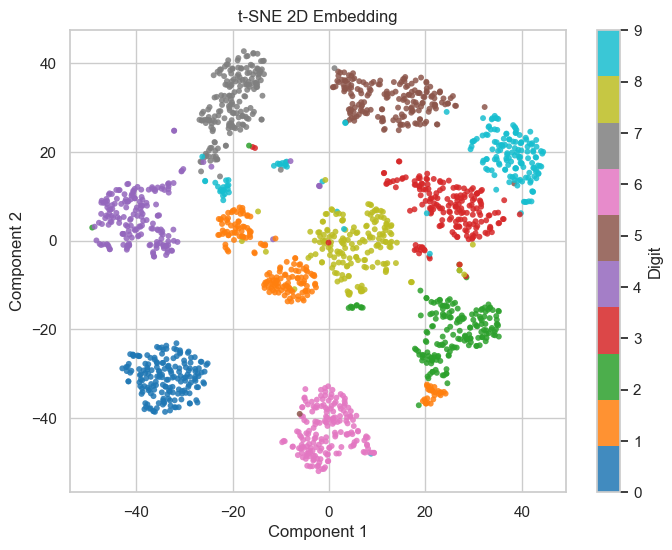

In [16]:
tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
Z_tsne_2d, tsne_time = timed_fit_transform(tsne_2d, X_scaled, "t-SNE 2D")

scatter = plot_2d_embedding(Z_tsne_2d, y, "t-SNE 2D Embedding")
plt.colorbar(scatter, label="Digit")
plt.show()

### نتیجه‌گیری t-SNE

t-SNE معمولا خوشه‌های محلی را واضح‌تر از PCA نمایش می‌دهد و برای تحلیل بصری بسیار قدرتمند است. با این حال نباید فاصله بین خوشه‌های دور یا اندازه خوشه‌ها را بیش از حد تفسیر کرد. t-SNE بیشتر برای visualization مناسب است، نه لزوما برای ساخت ویژگی پایدار در مدل‌های عملیاتی.

## ۱۵. مقایسه بصری روش‌های دوبعدی

در این بخش خروجی دوبعدی روش‌های مختلف کنار هم قرار می‌گیرد تا تفاوت دیداری آن‌ها مشخص شود. روش‌های خطی معمولا ساختار کلی را نشان می‌دهند، در حالی که روش‌های غیرخطی ممکن است خوشه‌های محلی را واضح‌تر کنند.

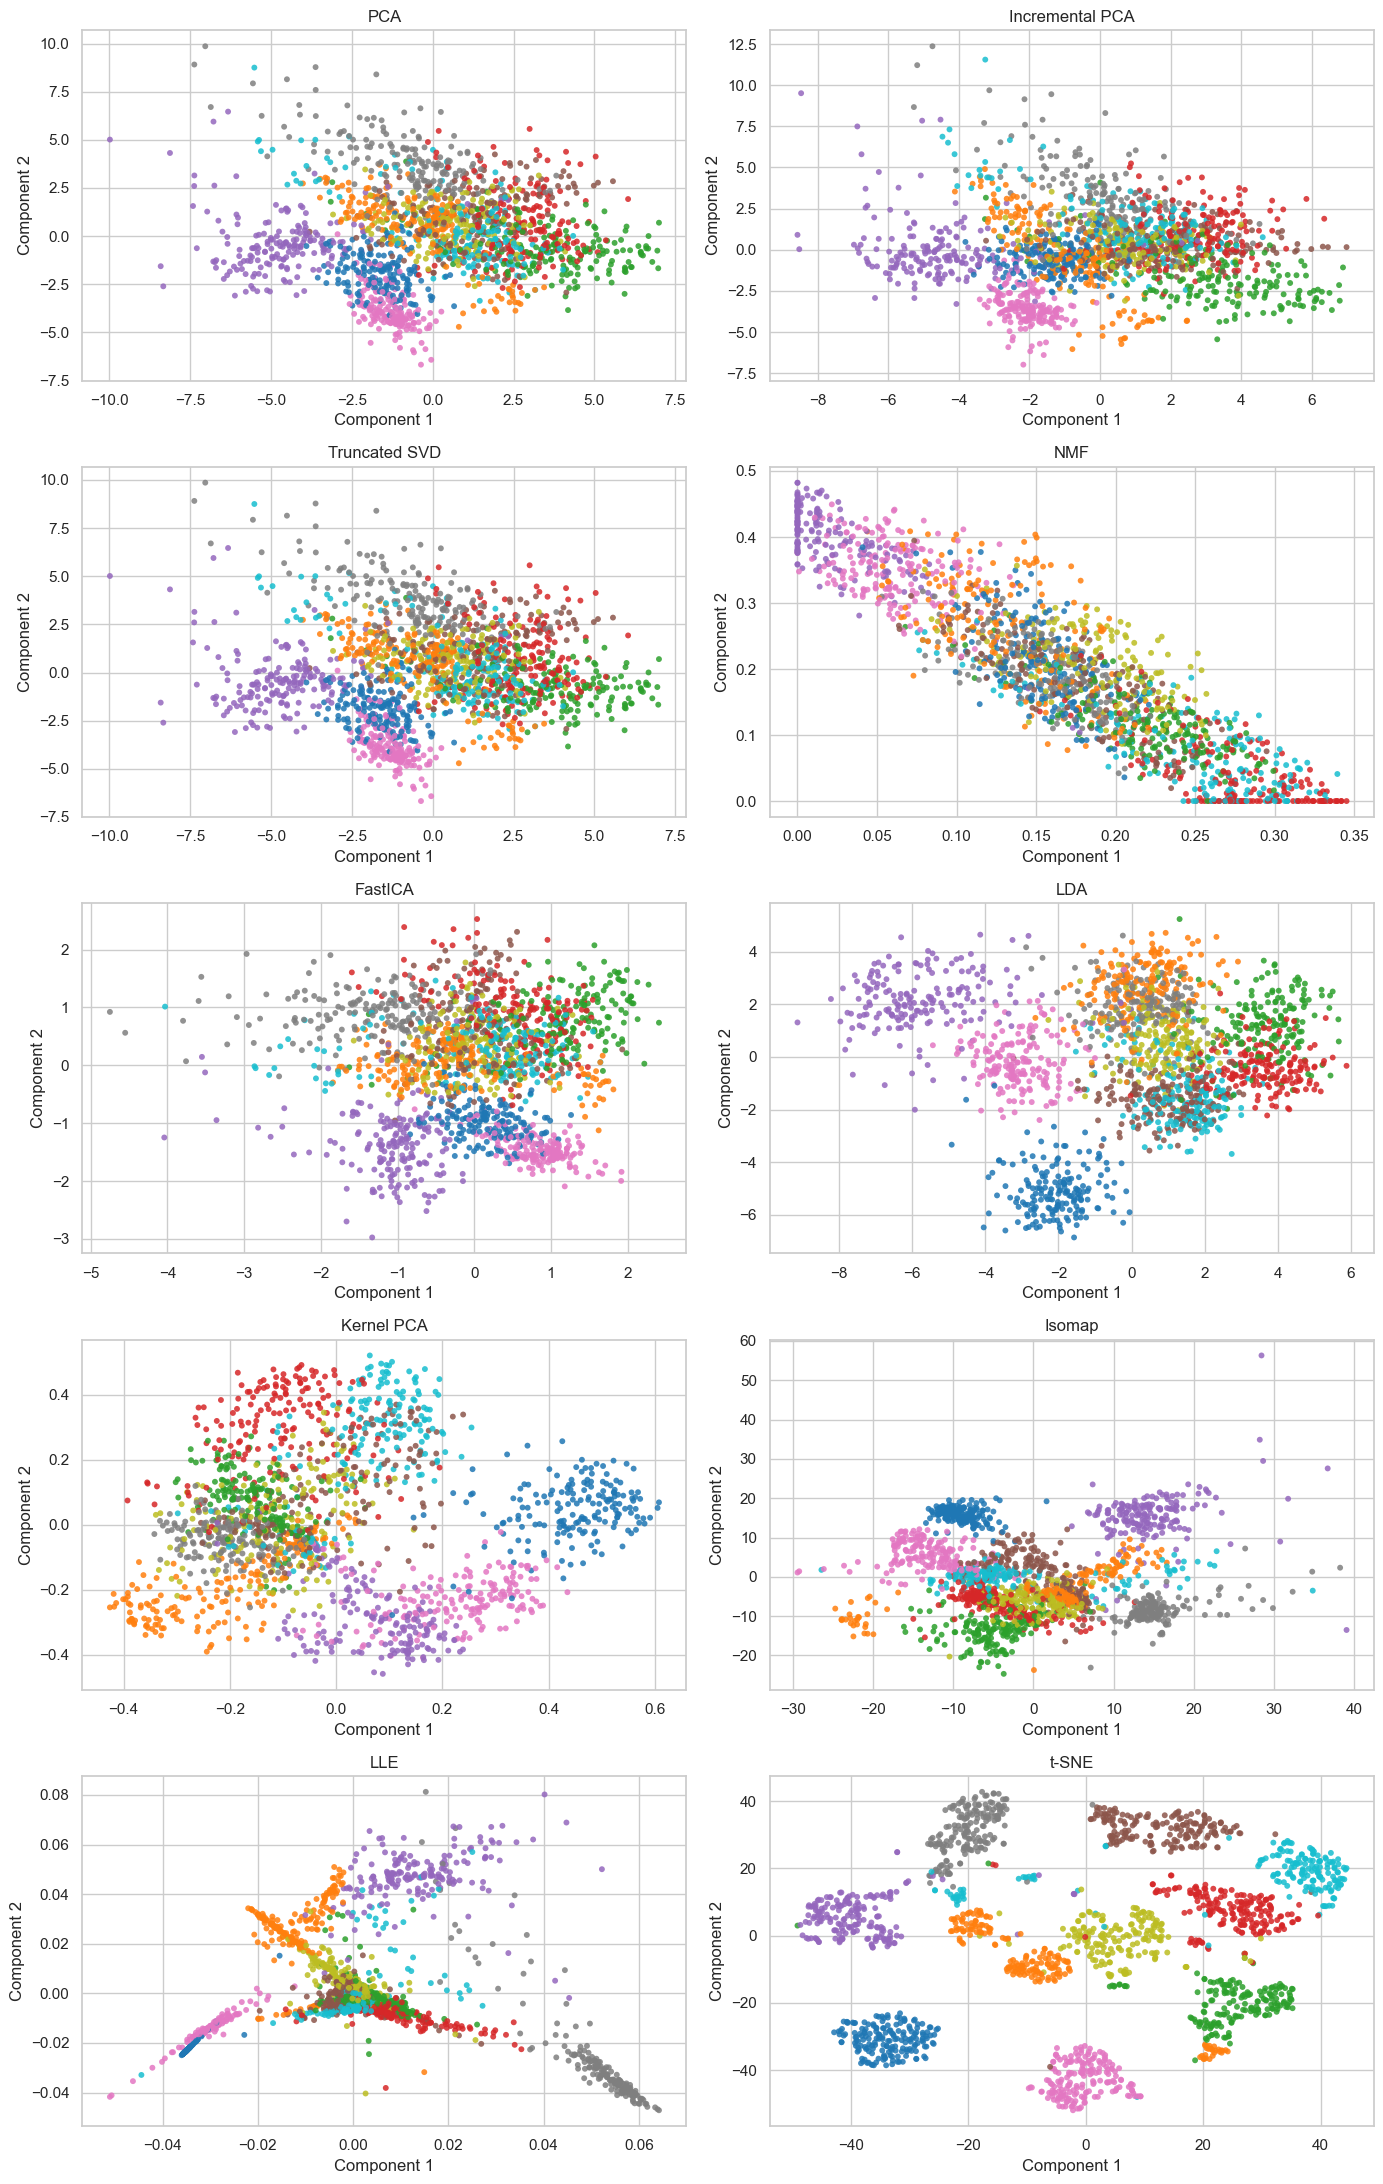

In [17]:
embeddings = {
    "PCA": Z_pca_2d,
    "Incremental PCA": Z_ipca_2d,
    "Truncated SVD": Z_svd_2d,
    "NMF": Z_nmf_2d,
    "FastICA": Z_ica_2d,
    "LDA": Z_lda_2d,
    "Kernel PCA": Z_kpca_2d,
    "Isomap": Z_isomap_2d,
    "LLE": Z_lle_2d,
    "t-SNE": Z_tsne_2d,
}

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
for ax, (name, Z) in zip(axes.ravel(), embeddings.items()):
    plot_2d_embedding(Z, y, name, ax=ax)
plt.tight_layout()
plt.show()

### نتیجه‌گیری مقایسه بصری

روش‌های مختلف لزوما هدف یکسانی ندارند. PCA و SVD بیشتر برای حفظ واریانس کلی مناسب‌اند. LDA جداسازی کلاسی را هدف می‌گیرد. روش‌هایی مانند Isomap، LLE و t-SNE ساختار محلی یا manifold را برجسته می‌کنند. بنابراین بهترین روش به هدف تحلیل وابسته است: تصویرسازی، فشرده‌سازی، حذف نویز، یا آماده‌سازی داده برای مدل‌سازی.

## ۱۶. مقایسه کمی با Trustworthiness

برای embeddingهای دوبعدی می‌توان بررسی کرد که همسایگی‌های محلی داده اصلی تا چه حد حفظ شده‌اند. معیار `trustworthiness` برای همین هدف استفاده می‌شود.

این معیار کیفیت طبقه‌بندی را اندازه نمی‌گیرد؛ بلکه حفظ روابط محلی را ارزیابی می‌کند.

,method,trustworthiness,fit_transform_time_sec
9,t-SNE,0.9864,7.7608
7,Isomap,0.8786,1.5921
8,LLE,0.8522,0.4677
4,FastICA,0.8178,0.0361
2,Truncated SVD,0.8163,0.0140
0,PCA,0.8163,0.0249
1,Incremental PCA,0.7941,0.0983
6,Kernel PCA,0.7896,0.3030
5,LDA,0.7646,NaN
3,NMF,0.7024,0.0541


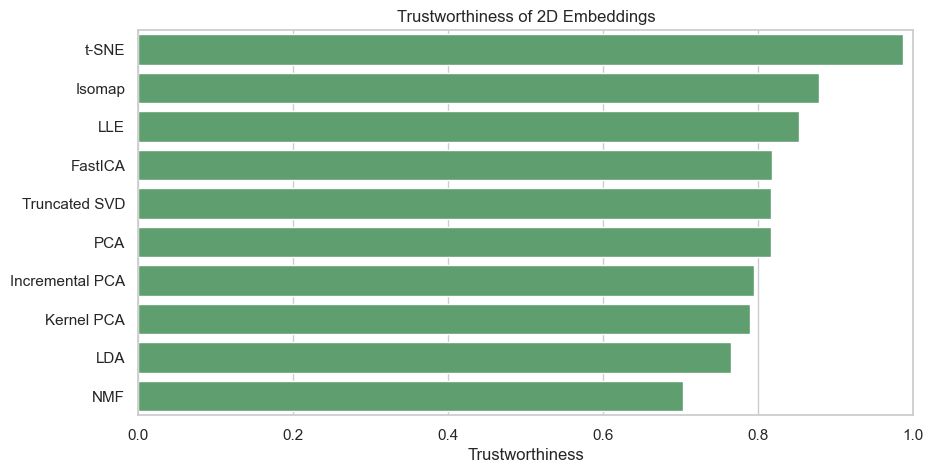

In [18]:
time_map = {
    "PCA": pca_time,
    "Incremental PCA": ipca_time,
    "Truncated SVD": svd_time,
    "NMF": nmf_time,
    "FastICA": ica_time,
    "LDA": lda_time,
    "Kernel PCA": kpca_time,
    "Isomap": isomap_time,
    "LLE": lle_time,
    "t-SNE": tsne_time,
}

trust_rows = []
for name, Z in embeddings.items():
    input_for_metric = X_nonnegative if name == "NMF" else X_scaled
    trust_rows.append(
        {
            "method": name,
            "trustworthiness": trustworthiness(input_for_metric, Z, n_neighbors=10),
            "fit_transform_time_sec": time_map[name],
        }
    )

trust_df = pd.DataFrame(trust_rows).sort_values("trustworthiness", ascending=False)
display(trust_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=trust_df, x="trustworthiness", y="method", color="#55A868")
plt.xlim(0, 1)
plt.title("Trustworthiness of 2D Embeddings")
plt.xlabel("Trustworthiness")
plt.ylabel("")
plt.show()

### نتیجه‌گیری Trustworthiness

مقدار بالاتر trustworthiness نشان می‌دهد همسایگی‌های محلی در فضای دوبعدی بهتر حفظ شده‌اند. روش‌هایی مانند t-SNE معمولا در این معیار عملکرد خوبی دارند، چون دقیقا برای حفظ ساختار محلی طراحی شده‌اند. اما این معیار به تنهایی کافی نیست؛ یک embedding ممکن است همسایگی‌ها را خوب حفظ کند، اما برای مدل‌سازی یا تفسیر مؤلفه‌ها مناسب نباشد.

## ۱۷. استخراج ویژگی برای مدل‌سازی

کاهش بُعد فقط برای تصویرسازی نیست. می‌توان ویژگی‌های استخراج‌شده را به مدل طبقه‌بندی داد و عملکرد را بررسی کرد.

در این بخش، ویژگی‌های ۳۰ بعدی از چند روش ساخته می‌شوند و سپس یک مدل KNN ساده روی آن‌ها ارزیابی می‌شود. هدف این است که ببینیم کاهش بُعد تا چه حد اطلاعات مفید برای طبقه‌بندی را حفظ کرده است.

,method,n_features,knn_accuracy,knn_f1_macro
5,LDA 9,9,0.9733,0.9730
2,Incremental PCA 30,30,0.9689,0.9686
1,PCA 30,30,0.9667,0.9663
3,Truncated SVD 30,30,0.9667,0.9663
0,Original 64 features,64,0.9644,0.9643
4,NMF 30,30,0.8867,0.8805


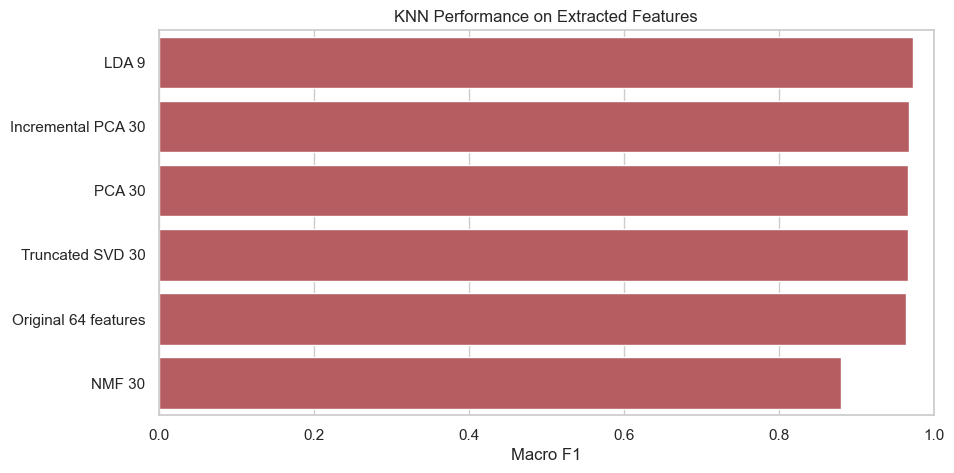

In [19]:
feature_sets = {}

feature_sets["Original 64 features"] = X_scaled
feature_sets["PCA 30"] = PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(X_scaled)
feature_sets["Incremental PCA 30"] = IncrementalPCA(n_components=30, batch_size=128).fit_transform(X_scaled)
feature_sets["Truncated SVD 30"] = TruncatedSVD(n_components=30, random_state=RANDOM_STATE).fit_transform(X_scaled)
feature_sets["NMF 30"] = NMF(n_components=30, init="nndsvda", max_iter=1000, random_state=RANDOM_STATE).fit_transform(X_nonnegative)
feature_sets["LDA 9"] = LinearDiscriminantAnalysis(n_components=9).fit_transform(X_scaled, y)

feature_report = [classifier_report_for_features(Z, y, name) for name, Z in feature_sets.items()]
feature_report_df = pd.DataFrame(feature_report).sort_values("knn_f1_macro", ascending=False)
display(feature_report_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_report_df, x="knn_f1_macro", y="method", color="#C44E52")
plt.xlim(0, 1)
plt.title("KNN Performance on Extracted Features")
plt.xlabel("Macro F1")
plt.ylabel("")
plt.show()

### نتیجه‌گیری استخراج ویژگی برای مدل‌سازی

اگر ویژگی‌های کاهش‌یافته عملکردی نزدیک به ویژگی‌های اصلی داشته باشند، روش کاهش بُعد توانسته اطلاعات مهم را حفظ کند. PCA و SVD معمولا با تعداد مؤلفه کافی عملکرد مناسبی دارند. LDA به دلیل استفاده از برچسب‌ها می‌تواند نمایش بسیار فشرده اما کلاسی‌تری بسازد. NMF بسته به ساختار داده ممکن است تفسیرپذیر باشد، اما همیشه بهترین عملکرد طبقه‌بندی را ندارد.

## ۱۸. اثر تعداد مؤلفه‌ها بر عملکرد

انتخاب تعداد مؤلفه‌ها یکی از تصمیم‌های اصلی در کاهش بُعد است. تعداد کم مؤلفه‌ها باعث فشرده‌سازی بیشتر می‌شود، اما ممکن است اطلاعات مهم حذف شود. تعداد زیاد مؤلفه‌ها اطلاعات بیشتری حفظ می‌کند، اما کاهش بُعد کمتری رخ می‌دهد.

در این بخش اثر تعداد مؤلفه‌های PCA بر عملکرد KNN بررسی می‌شود.

,method,n_features,knn_accuracy,knn_f1_macro,explained_variance
0,PCA 2,2,0.5467,0.5336,0.2159
1,PCA 5,5,0.8356,0.8313,0.4140
2,PCA 10,10,0.9289,0.9278,0.5887
3,PCA 15,15,0.9556,0.9554,0.7090
4,PCA 20,20,0.9622,0.9616,0.7931
5,PCA 30,30,0.9667,0.9663,0.8932
6,PCA 40,40,0.9689,0.9687,0.9508
7,PCA 50,50,0.9644,0.9641,0.9828
8,PCA 64,64,0.9644,0.9643,1.0000


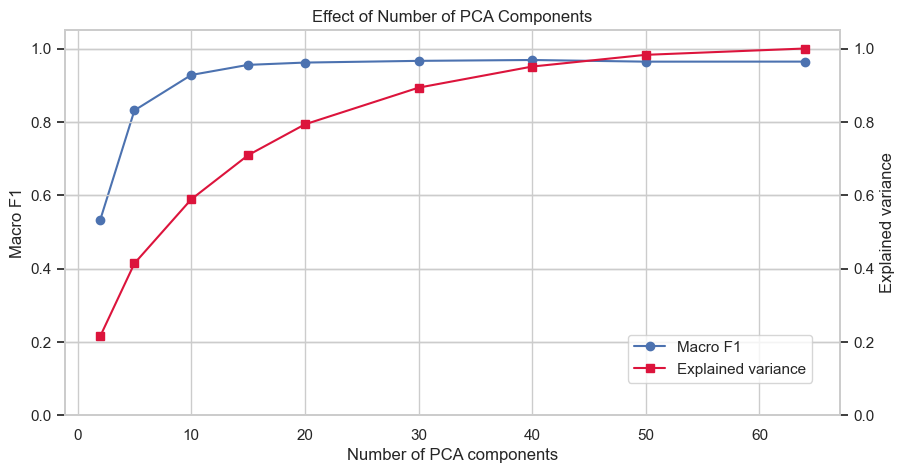

In [20]:
n_components_grid = [2, 5, 10, 15, 20, 30, 40, 50, 64]
component_rows = []

for n_comp in n_components_grid:
    if n_comp == 64:
        Z = X_scaled
        explained_variance = 1.0
    else:
        pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
        Z = pca.fit_transform(X_scaled)
        explained_variance = pca.explained_variance_ratio_.sum()
    report = classifier_report_for_features(Z, y, f"PCA {n_comp}")
    report["explained_variance"] = explained_variance
    component_rows.append(report)

component_df = pd.DataFrame(component_rows)
display(component_df.round(4))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(component_df["n_features"], component_df["knn_f1_macro"], marker="o", label="Macro F1")
ax1.set_xlabel("Number of PCA components")
ax1.set_ylabel("Macro F1")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(component_df["n_features"], component_df["explained_variance"], marker="s", color="crimson", label="Explained variance")
ax2.set_ylabel("Explained variance")
ax2.set_ylim(0, 1.05)

plt.title("Effect of Number of PCA Components")
fig.legend(loc="lower right", bbox_to_anchor=(0.88, 0.16))
plt.show()

### نتیجه‌گیری تعداد مؤلفه‌ها

افزایش تعداد مؤلفه‌ها معمولا باعث حفظ اطلاعات بیشتر و بهبود عملکرد مدل می‌شود، اما پس از یک نقطه بازدهی کاهش می‌یابد. انتخاب تعداد مؤلفه‌ها باید بر اساس هدف انجام شود: اگر هدف تصویرسازی باشد، ۲ یا ۳ مؤلفه کافی است؛ اگر هدف مدل‌سازی باشد، باید تعداد مؤلفه‌ای انتخاب شود که عملکرد را با فشرده‌سازی مناسب متعادل کند.

## ۱۹. Pipeline استاندارد برای استخراج ویژگی و طبقه‌بندی

در پروژه‌های واقعی، بهتر است scaling، استخراج ویژگی و مدل‌سازی داخل `Pipeline` قرار گیرند. این کار از نشت داده جلوگیری می‌کند، مخصوصا هنگام Cross Validation.

در این بخش یک pipeline شامل StandardScaler، PCA و SVC ارزیابی می‌شود.

In [21]:
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=30, random_state=RANDOM_STATE)),
        ("classifier", SVC(kernel="rbf", gamma="scale", C=5)),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
    return_train_score=True,
)

pipeline_summary = pd.DataFrame(
    {
        "metric": ["accuracy", "f1_macro"],
        "train_mean": [
            cv_results["train_accuracy"].mean(),
            cv_results["train_f1_macro"].mean(),
        ],
        "train_std": [
            cv_results["train_accuracy"].std(),
            cv_results["train_f1_macro"].std(),
        ],
        "validation_mean": [
            cv_results["test_accuracy"].mean(),
            cv_results["test_f1_macro"].mean(),
        ],
        "validation_std": [
            cv_results["test_accuracy"].std(),
            cv_results["test_f1_macro"].std(),
        ],
    }
)
display(pipeline_summary.round(4))

,metric,train_mean,train_std,validation_mean,validation_std
0,accuracy,0.9997,0.0003,0.9816,0.0062
1,f1_macro,0.9997,0.0003,0.9816,0.0063


### نتیجه‌گیری Pipeline

وقتی استخراج ویژگی قبل از تقسیم داده یا خارج از Cross Validation انجام شود، ممکن است اطلاعات داده اعتبارسنجی وارد مرحله آموزش شود و نتیجه بیش از حد خوش‌بینانه باشد. استفاده از `Pipeline` باعث می‌شود هر مرحله فقط روی داده آموزش همان fold fit شود. این استاندارد برای ارزیابی قابل اعتماد ضروری است.

## ۲۰. مقایسه نهایی روش‌ها

روش‌های مختلف کاهش بُعد از نظر هدف، تفسیرپذیری، هزینه محاسباتی و کاربرد تفاوت دارند. جدول زیر جمع‌بندی عملی روش‌های بررسی‌شده را نشان می‌دهد.

In [22]:
comparison_table = pd.DataFrame(
    [
        {
            "method": "PCA",
            "supervised": "No",
            "linear": "Yes",
            "main_use": "فشرده‌سازی، حذف نویز، تصویرسازی سریع",
            "strength": "ساده، سریع، قابل تفسیر با explained variance",
            "limitation": "فقط ساختار خطی را حفظ می‌کند",
        },
        {
            "method": "Incremental PCA",
            "supervised": "No",
            "linear": "Yes",
            "main_use": "PCA برای داده بزرگ یا batch processing",
            "strength": "مصرف حافظه کمتر",
            "limitation": "برای داده کوچک مزیت خاصی نسبت به PCA ندارد",
        },
        {
            "method": "Truncated SVD",
            "supervised": "No",
            "linear": "Yes",
            "main_use": "داده sparse، متن‌کاوی، LSA",
            "strength": "مناسب برای ماتریس‌های sparse",
            "limitation": "تفسیر آن وابسته به نوع داده است",
        },
        {
            "method": "NMF",
            "supervised": "No",
            "linear": "Approx.",
            "main_use": "داده غیرمنفی، topic/model parts",
            "strength": "مؤلفه‌های غیرمنفی و گاهی تفسیرپذیر",
            "limitation": "نیازمند داده غیرمنفی و حساس به initialization",
        },
        {
            "method": "FastICA",
            "supervised": "No",
            "linear": "Yes",
            "main_use": "جداسازی منبع و سیگنال",
            "strength": "یافتن منابع مستقل",
            "limitation": "برای همه داده‌ها مناسب نیست",
        },
        {
            "method": "LDA",
            "supervised": "Yes",
            "linear": "Yes",
            "main_use": "استخراج ویژگی برای جداسازی کلاسی",
            "strength": "استفاده از برچسب و فشرده‌سازی مؤثر برای classification",
            "limitation": "نیازمند label و حداکثر C-1 مؤلفه",
        },
        {
            "method": "Kernel PCA",
            "supervised": "No",
            "linear": "No",
            "main_use": "کاهش بُعد غیرخطی",
            "strength": "مدل‌کردن ساختارهای غیرخطی",
            "limitation": "حساس به kernel و پارامترها",
        },
        {
            "method": "Isomap",
            "supervised": "No",
            "linear": "No",
            "main_use": "manifold learning",
            "strength": "حفظ فاصله‌های ژئودزیک",
            "limitation": "حساس به تعداد همسایه‌ها",
        },
        {
            "method": "LLE",
            "supervised": "No",
            "linear": "No",
            "main_use": "حفظ ساختار محلی",
            "strength": "تمرکز بر روابط محلی",
            "limitation": "حساس به نویز و n_neighbors",
        },
        {
            "method": "t-SNE",
            "supervised": "No",
            "linear": "No",
            "main_use": "تصویرسازی خوشه‌ها",
            "strength": "نمایش قوی ساختار محلی",
            "limitation": "مناسب تفسیر فاصله‌های جهانی یا feature pipeline عمومی نیست",
        },
    ]
)

display(comparison_table)

,method,supervised,linear,main_use,strength,limitation
0,PCA,No,Yes,فشرده‌سازی، حذف نویز، تصویرسازی سریع,ساده، سریع، قابل تفسیر با explained variance,فقط ساختار خطی را حفظ می‌کند
1,Incremental PCA,No,Yes,PCA برای داده بزرگ یا batch processing,مصرف حافظه کمتر,برای داده کوچک مزیت خاصی نسبت به PCA ندارد
2,Truncated SVD,No,Yes,داده sparse، متن‌کاوی، LSA,مناسب برای ماتریس‌های sparse,تفسیر آن وابسته به نوع داده است
3,NMF,No,Approx.,داده غیرمنفی، topic/model parts,مؤلفه‌های غیرمنفی و گاهی تفسیرپذیر,نیازمند داده غیرمنفی و حساس به initialization
4,FastICA,No,Yes,جداسازی منبع و سیگنال,یافتن منابع مستقل,برای همه داده‌ها مناسب نیست
5,LDA,Yes,Yes,استخراج ویژگی برای جداسازی کلاسی,استفاده از برچسب و فشرده‌سازی مؤثر برای classi...,نیازمند label و حداکثر C-1 مؤلفه
6,Kernel PCA,No,No,کاهش بُعد غیرخطی,مدل‌کردن ساختارهای غیرخطی,حساس به kernel و پارامترها
7,Isomap,No,No,manifold learning,حفظ فاصله‌های ژئودزیک,حساس به تعداد همسایه‌ها
8,LLE,No,No,حفظ ساختار محلی,تمرکز بر روابط محلی,حساس به نویز و n_neighbors
9,t-SNE,No,No,تصویرسازی خوشه‌ها,نمایش قوی ساختار محلی,مناسب تفسیر فاصله‌های جهانی یا feature pipelin...


## ۲۱. جمع‌بندی نهایی

استخراج ویژگی و کاهش بُعد فقط یک ابزار برای کوچک‌کردن تعداد ستون‌ها نیست؛ بلکه روشی برای تغییر نمایش داده است. انتخاب روش مناسب به هدف مسئله وابسته است:

- اگر هدف فشرده‌سازی و حفظ واریانس باشد، PCA انتخاب پایه و قدرتمندی است.
- اگر داده sparse باشد، Truncated SVD معمولا مناسب‌تر از PCA است.
- اگر داده غیرمنفی و تفسیرپذیری part-based مهم باشد، NMF گزینه مناسبی است.
- اگر برچسب‌ها موجود باشند و هدف طبقه‌بندی باشد، LDA می‌تواند نمایش بسیار فشرده و مؤثر بسازد.
- اگر ساختار داده غیرخطی باشد، Kernel PCA، Isomap و LLE قابل بررسی هستند.
- اگر هدف اصلی تصویرسازی خوشه‌های محلی باشد، t-SNE معمولا بسیار مفید است.

در عمل، بهترین انتخاب با ترکیب دانش مسئله، تحلیل بصری، معیارهای کمی مانند trustworthiness، و ارزیابی عملکرد مدل downstream انجام می‌شود.